In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
data = pd.read_csv("loan_data.csv")

In [12]:
data


,Age,Income,LoanAmount,CreditScore,Approved
0,22,71948,35000,561,1
1,21,12282,1000,504,0
2,25,12438,5500,635,1
3,23,79753,35000,675,1
4,24,66135,35000,586,1
...,...,...,...,...,...
44995,27,47971,15000,645,1
44996,37,65800,9000,621,1
44997,33,56942,2771,668,1
44998,29,33164,12000,604,1


In [13]:
data.shape

(45000, 5)

In [14]:
data.head(5)

,Age,Income,LoanAmount,CreditScore,Approved
0,22,71948,35000,561,1
1,21,12282,1000,504,0
2,25,12438,5500,635,1
3,23,79753,35000,675,1
4,24,66135,35000,586,1


In [15]:
data.tail(10)

,Age,Income,LoanAmount,CreditScore,Approved
44990,31,136832,12319,722,1
44991,24,37786,13500,612,1
44992,23,40925,9000,487,1
44993,27,35512,5000,505,1
44994,24,31924,12229,678,1
44995,27,47971,15000,645,1
44996,37,65800,9000,621,1
44997,33,56942,2771,668,1
44998,29,33164,12000,604,1
44999,24,51609,6665,628,1


In [16]:
print('No. of rows',data.shape[0])
print('No. of columns',data.shape[1])

No. of rows 45000
No. of columns 5


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Age          45000 non-null  int64
 1   Income       45000 non-null  int64
 2   LoanAmount   45000 non-null  int64
 3   CreditScore  45000 non-null  int64
 4   Approved     45000 non-null  int64
dtypes: int64(5)
memory usage: 1.7 MB


In [18]:
data.describe()

,Age,Income,LoanAmount,CreditScore,Approved
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,9583.157556,632.608756,0.222222
std,6.045108,8.042250e+04,6314.886691,50.435865,0.415744
min,20.000000,8.000000e+03,500.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,5000.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,8000.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,12237.250000,670.000000,0.000000
max,144.000000,7.200766e+06,35000.000000,850.000000,1.000000


In [26]:
data.dtypes

,0
Age,int64
Income,int64
LoanAmount,int64
CreditScore,int64
Approved,int64


The data type of all of the values.

In [19]:
data.isna().sum()

,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
Approved,0


This shows that there are no null values in any of the required colomn.

In [20]:
data.duplicated().sum()

np.int64(1)

This shows that there are no duplicate values in any of the required colomn.

In [21]:
(data["Age"] == 0).sum()

(data["Income"] == 0).sum()

(data["LoanAmount"] == 0).sum()

(data["CreditScore"] == 0).sum()

np.int64(0)

This shows that there are no zero values in any of the above colomn.

The Maximum AGE is shown 144 in the data which is not resonable, so we need to handle that issue.

In [23]:
data[data["Age"] > 110]

,Age,Income,LoanAmount,CreditScore,Approved
81,144,300616,4800,789,0
183,144,241424,6000,807,0
575,123,97140,20400,805,0
747,123,94723,20000,714,0
32297,144,7200766,5000,850,0
37930,116,5545545,3823,708,0


In [24]:
data = data[data["Age"] <= 110]

Now we have the resonable value for the age of the people applying for the loan.

In [29]:
#AGAIN

print(data.describe())

print("This shows the max value for age as 109 years.")

                Age        Income    LoanAmount   CreditScore      Approved
count  44994.000000  4.499400e+04  44994.000000  44994.000000  44994.000000
mean      27.750233  8.003016e+04   9583.101458    632.589256      0.222252
std        5.922073  6.838260e+04   6314.752681     50.407453      0.415764
min       20.000000  8.000000e+03    500.000000    390.000000      0.000000
25%       24.000000  4.719575e+04   5000.000000    601.000000      0.000000
50%       26.000000  6.704600e+04   8000.000000    640.000000      0.000000
75%       30.000000  9.578100e+04  12236.500000    670.000000      0.000000
max      109.000000  5.556399e+06  35000.000000    792.000000      1.000000
This shows the max value for age as 109 years.


# Now we will start with the visual representation of the data relation within and with other factors.

### Outlier Detection

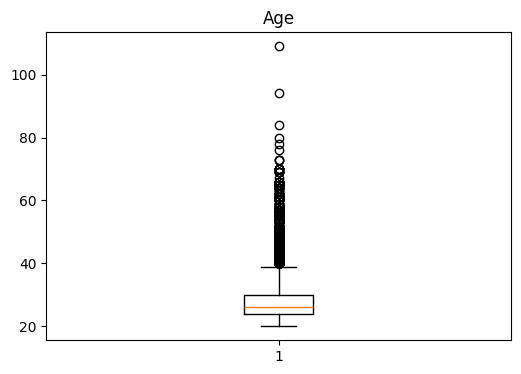

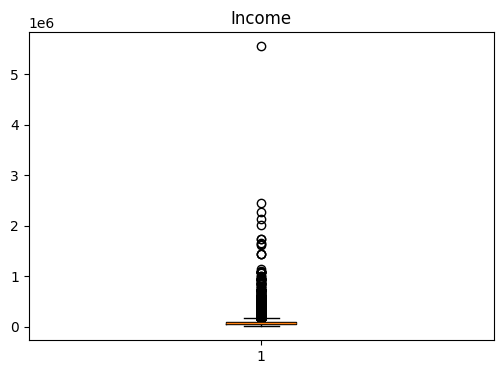

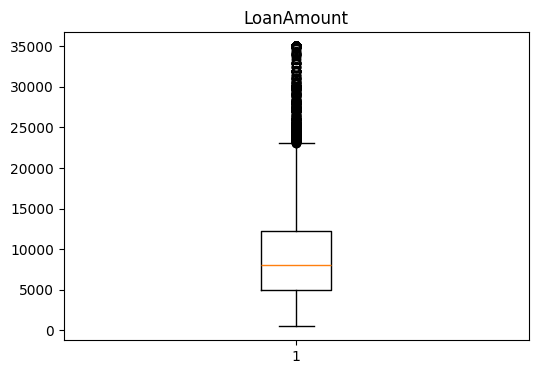

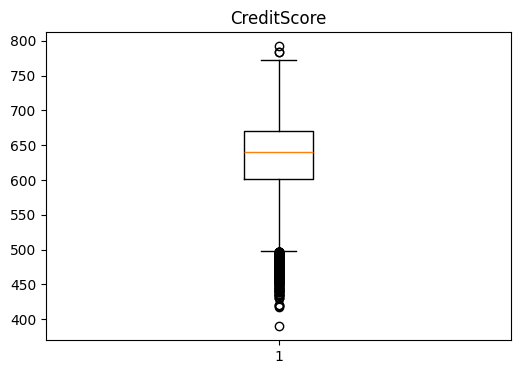

In [31]:
for col in data.columns[:-1]:
    plt.figure(figsize=(6,4))
    plt.boxplot(data[col])
    plt.title(col)
    plt.show()

Here we are looking for the outlier in all of the data which we have provided and we can see that not much of them are present and in decision tree the outliers are already handled.

### Distribution

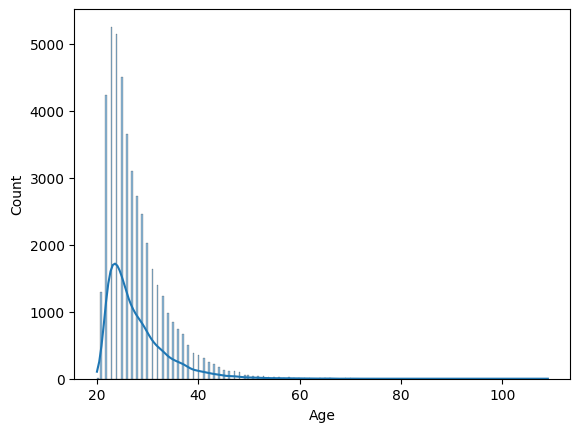

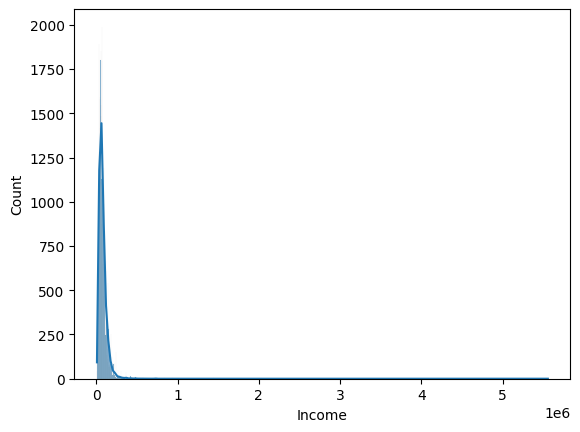

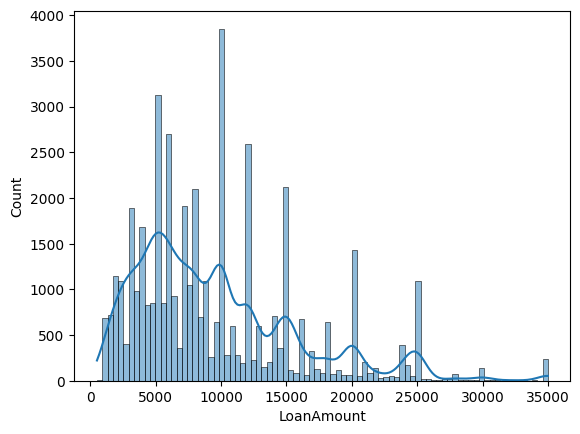

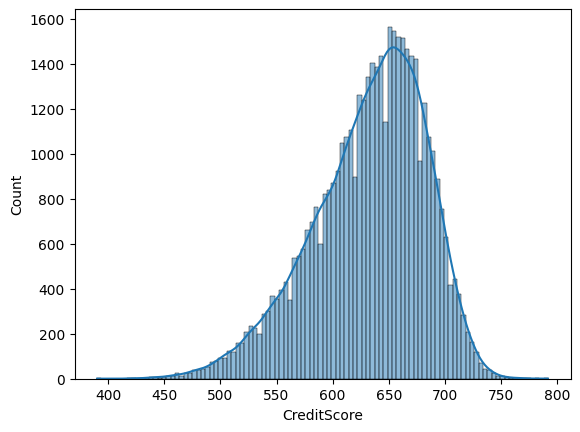

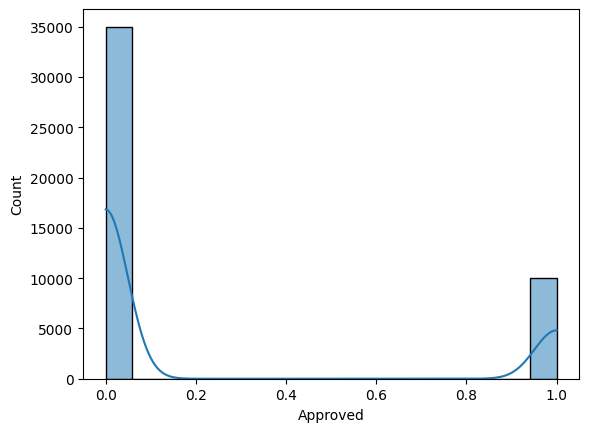

In [33]:
for col in data.columns:
    sns.histplot(data[col], kde=True)
    plt.show()

### Correlation

<Axes: >

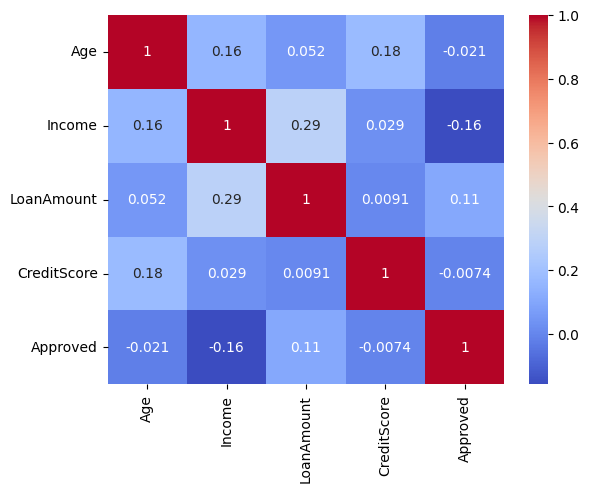

In [34]:
corr = data.corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

With the help of this heat map, we can see that the highest relation of a loan being approved is directly related to the credit score and next is income.

### Feature Relationships

<Axes: xlabel='Age', ylabel='LoanAmount'>

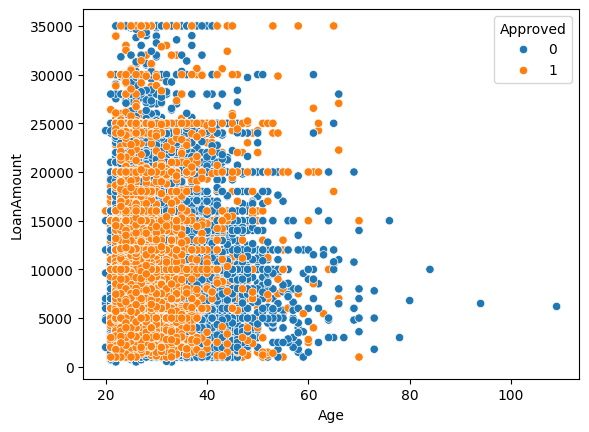

In [35]:
sns.scatterplot(
    data=data,
    x="Age",
    y="LoanAmount",
    hue="Approved"
)

The lower values in the range for loan amount and the age are having more chances of getting the loan approved.

<Axes: xlabel='Income', ylabel='LoanAmount'>

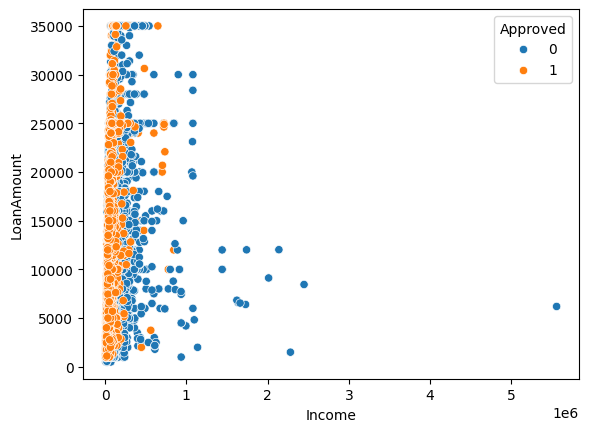

In [36]:
sns.scatterplot(
    data=data,
    x="Income",
    y="LoanAmount",
    hue="Approved"
)

<Axes: xlabel='Income', ylabel='CreditScore'>

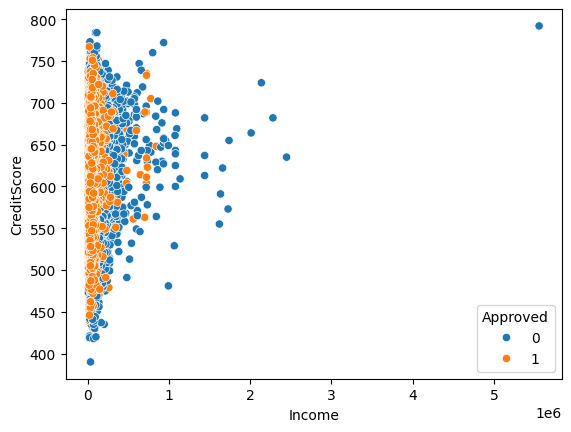

In [37]:
sns.scatterplot(
    data=data,
    x="Income",
    y="CreditScore",
    hue="Approved"
)

Income effects but not that much compared to the higher credit score.